dataset: [CIFAR-10 Image Dataset](https://cave.cs.toronto.edu/kriz/cifar.html)

In [72]:
import time
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from sklearn.metrics import precision_recall_fscore_support
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models



In [73]:
DATA_DIR = "./data"
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
 
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cuda


In [74]:
_train_raw = CIFAR10(root=DATA_DIR, train=True, download=True)
_test_raw = CIFAR10(root=DATA_DIR, train=False, download=True)

X_full = _train_raw.data                              # (50000, 32, 32, 3) uint8
y_full = np.array(_train_raw.targets, dtype=np.int64)
X_test = _test_raw.data                               # (10000, 32, 32, 3) uint8
y_test = np.array(_test_raw.targets, dtype=np.int64)

In [75]:
class CIFARDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).permute(2, 0, 1).float() / 255.0
        img = (img - MEAN) / STD
        return img, int(self.labels[idx])

In [76]:
full_ds = CIFARDataset(X_full, y_full)
test_ds = CIFARDataset(X_test, y_test)
train_ds, val_ds = random_split(full_ds, [45000, 5000],
                                generator=torch.Generator().manual_seed(SEED))
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 45000, Val: 5000, Test: 10000


In [77]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

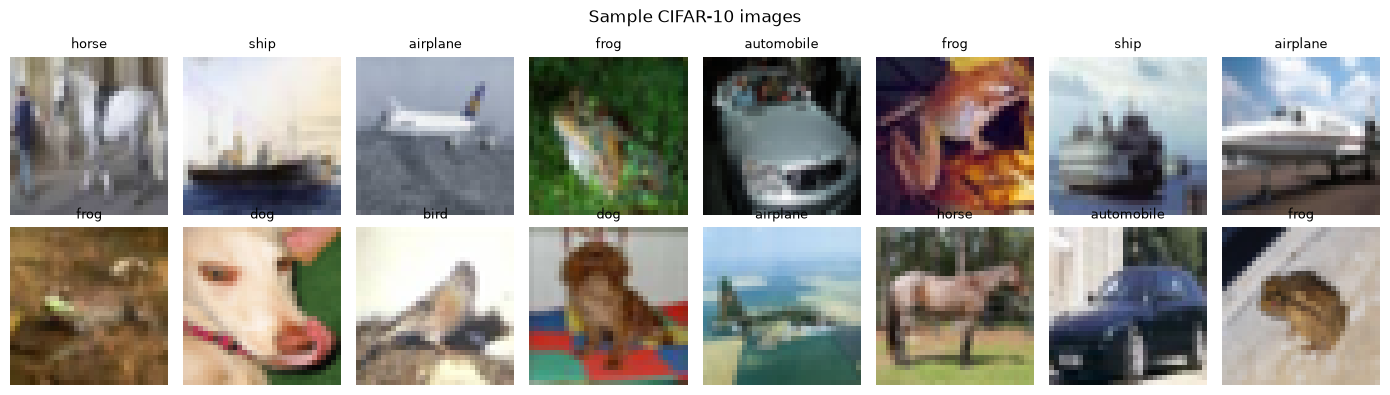

In [78]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.ravel(), np.random.choice(len(X_full), 16, replace=False)):
    ax.imshow(X_full[i])
    ax.set_title(CLASSES[y_full[i]], fontsize=9)
    ax.axis("off")
fig.suptitle("Sample CIFAR-10 images")
plt.tight_layout()
plt.show()

In [79]:
print(f"Image shape: {X_full.shape[1:]}, dtype: {X_full.dtype}, "
      f"pixel range: [{X_full.min()}, {X_full.max()}]")
ch_mean = (X_full / 255.0).mean(axis=(0, 1, 2))
ch_std = (X_full / 255.0).std(axis=(0, 1, 2))
print(f"Per-channel mean (RGB): {np.round(ch_mean, 4)}")
print(f"Per-channel std  (RGB): {np.round(ch_std, 4)}")
print(f"Missing/NaN values: {int(np.isnan(X_full.astype(float)).sum())}")

Image shape: (32, 32, 3), dtype: uint8, pixel range: [0, 255]
Per-channel mean (RGB): [0.4914 0.4822 0.4465]
Per-channel std  (RGB): [0.247  0.2435 0.2616]
Missing/NaN values: 0


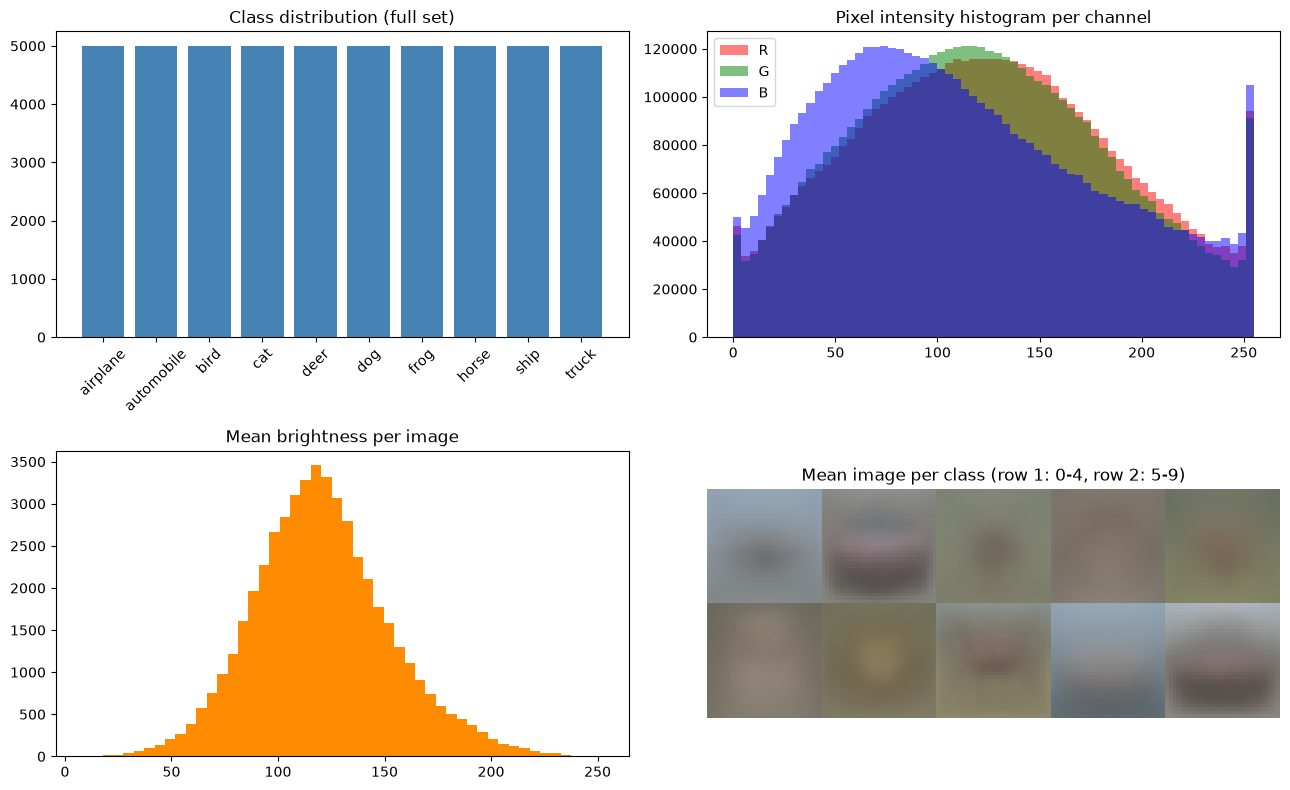

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

counts = np.bincount(y_full, minlength=10)
axes[0, 0].bar(CLASSES, counts, color="steelblue")
axes[0, 0].set_title("Class distribution (full set)")
axes[0, 0].tick_params(axis="x", rotation=45)

for c, color in zip(range(3), ["red", "green", "blue"]):
    axes[0, 1].hist(X_full[::10, :, :, c].ravel(), bins=64, alpha=0.5,
                    color=color, label="RGB"[c])
axes[0, 1].set_title("Pixel intensity histogram per channel")
axes[0, 1].legend()

brightness = X_full.mean(axis=(1, 2, 3))
axes[1, 0].hist(brightness, bins=50, color="darkorange")
axes[1, 0].set_title("Mean brightness per image")

mean_imgs = np.stack([X_full[y_full == c].mean(axis=0) for c in range(10)]).astype(np.uint8)
grid = np.concatenate([np.concatenate(mean_imgs[:5], axis=1),
                       np.concatenate(mean_imgs[5:], axis=1)], axis=0)
axes[1, 1].imshow(grid)
axes[1, 1].set_title("Mean image per class (row 1: 0-4, row 2: 5-9)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [81]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return total_loss / n, correct / n

In [82]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    preds, targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        total_loss += criterion(out, yb).item() * xb.size(0)
        n += xb.size(0)
        preds.append(out.argmax(1).cpu())
        targets.append(yb.cpu())
    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    prec, rec, f1, _ = precision_recall_fscore_support(
        targets, preds, average="macro", zero_division=0)
    return {"loss": total_loss / n, "accuracy": float((preds == targets).mean()),
            "precision": prec, "recall": rec, "f1": f1}

In [83]:
def build_resnet18(trainable_layers=()):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 10)  # new head, trainable
    for name in trainable_layers:
        for p in getattr(model, name).parameters():
            p.requires_grad = True
    return model


In [84]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout(0.25))

        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

In [85]:
def run_experiment(name, model):
    print(f"\n=== {name} ===")
    model = model.to(DEVICE)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=LR)

    history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc",
                               "val_precision", "val_recall", "val_f1"]}
    start = time.time()
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val = evaluate(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val["loss"])
        history["val_acc"].append(val["accuracy"])
        history["val_precision"].append(val["precision"])
        history["val_recall"].append(val["recall"])
        history["val_f1"].append(val["f1"])
        print(f"Epoch {epoch}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {val['loss']:.4f} acc {val['accuracy']:.4f} f1 {val['f1']:.4f}")
    train_time = time.time() - start

    test = evaluate(model, test_loader, criterion, DEVICE)
    print(f"Test: loss {test['loss']:.4f} acc {test['accuracy']:.4f} f1 {test['f1']:.4f}")

    results = {"history": history, "test": test, "trainable_params": trainable,
               "train_time_s": train_time,"model":model}
    plot_history(name, history)
    return results

In [86]:
def plot_history(name, h):
    epochs = range(1, len(h["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()

    axes[0].plot(epochs, h["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Validation")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(epochs, h["train_acc"], marker="o", label="Train")
    axes[1].plot(epochs, h["val_acc"], marker="o", label="Validation")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    for ax, key, title in zip(axes[2:], ["val_precision", "val_recall", "val_f1"],
                              ["Validation Precision (macro)",
                               "Validation Recall (macro)",
                               "Validation F1 (macro)"]):
        ax.plot(epochs, h[key], marker="o", color="tab:green")
        ax.set_title(title)

    axes[5].plot(epochs, np.array(h["train_loss"]) - np.array(h["val_loss"]),
                 marker="o", color="tab:red")
    axes[5].axhline(0, color="gray", linewidth=0.8)
    axes[5].set_title("Loss gap (train - val)")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)
    fig.suptitle(name, fontsize=14)
    plt.tight_layout()
    plt.show()

In [87]:
all_results = {}


=== ResNet18 (fc only) ===
Trainable params: 5,130 / 11,181,642
Epoch 1/10 | train loss 1.7748 acc 0.3836 | val loss 1.6260 acc 0.4324 f1 0.4218
Epoch 2/10 | train loss 1.5980 acc 0.4454 | val loss 1.5942 acc 0.4374 f1 0.4334
Epoch 3/10 | train loss 1.5678 acc 0.4571 | val loss 1.5792 acc 0.4542 f1 0.4448
Epoch 4/10 | train loss 1.5551 acc 0.4594 | val loss 1.5564 acc 0.4564 f1 0.4536
Epoch 5/10 | train loss 1.5375 acc 0.4651 | val loss 1.5616 acc 0.4592 f1 0.4505
Epoch 6/10 | train loss 1.5438 acc 0.4647 | val loss 1.5511 acc 0.4588 f1 0.4498
Epoch 7/10 | train loss 1.5327 acc 0.4677 | val loss 1.5623 acc 0.4556 f1 0.4506
Epoch 8/10 | train loss 1.5312 acc 0.4680 | val loss 1.5757 acc 0.4548 f1 0.4485
Epoch 9/10 | train loss 1.5240 acc 0.4715 | val loss 1.5507 acc 0.4566 f1 0.4505
Epoch 10/10 | train loss 1.5236 acc 0.4696 | val loss 1.5494 acc 0.4620 f1 0.4550
Test: loss 1.5737 acc 0.4595 f1 0.4525


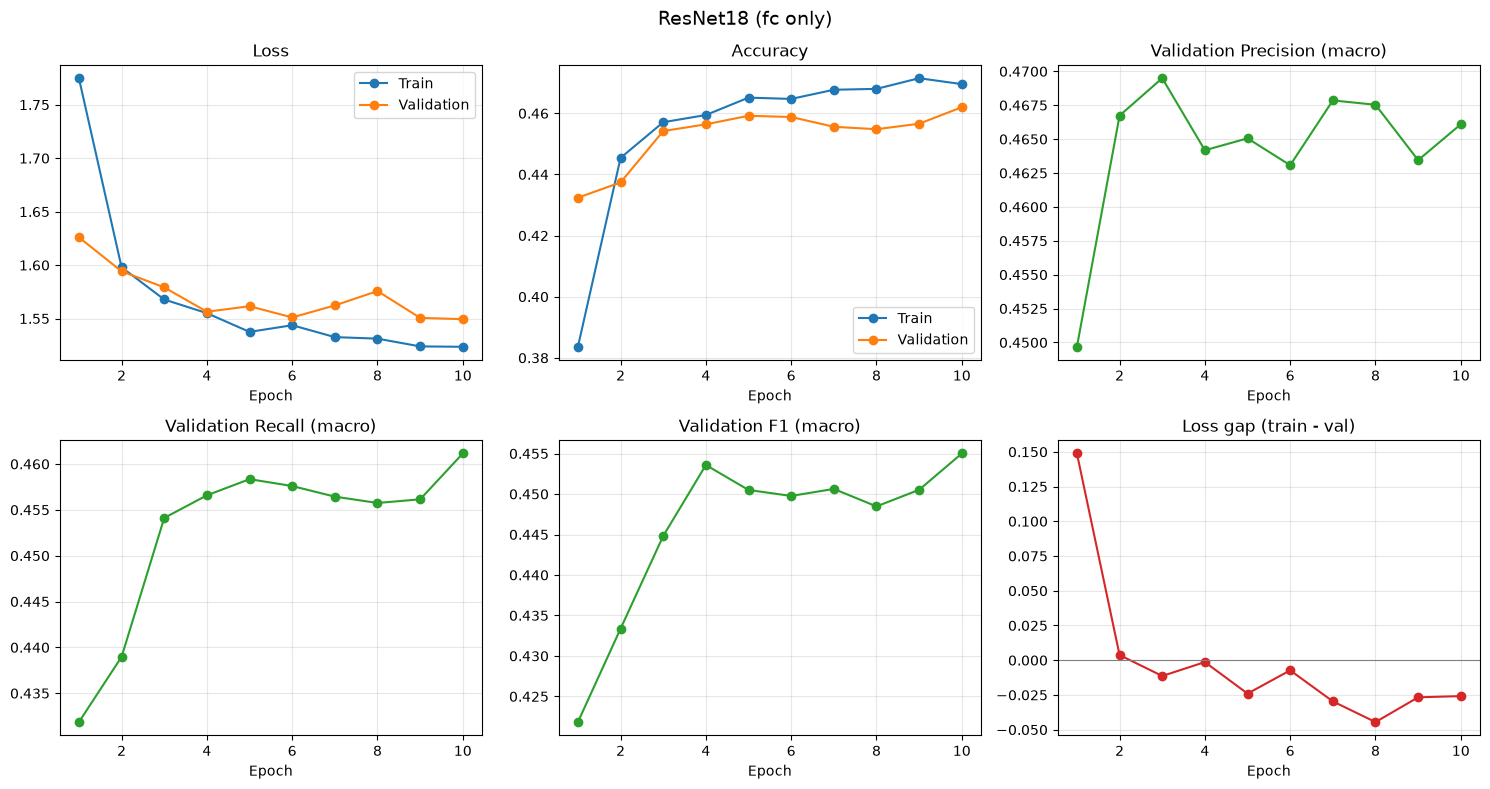


=== ResNet18 (layer4 + fc) ===
Trainable params: 8,398,858 / 11,181,642
Epoch 1/10 | train loss 1.1037 acc 0.6177 | val loss 0.9345 acc 0.6802 f1 0.6790
Epoch 2/10 | train loss 0.7751 acc 0.7315 | val loss 0.9011 acc 0.6874 f1 0.6867
Epoch 3/10 | train loss 0.6162 acc 0.7834 | val loss 0.9024 acc 0.6992 f1 0.6982
Epoch 4/10 | train loss 0.4818 acc 0.8300 | val loss 0.9443 acc 0.6972 f1 0.6959
Epoch 5/10 | train loss 0.3813 acc 0.8657 | val loss 1.1262 acc 0.6860 f1 0.6874
Epoch 6/10 | train loss 0.3048 acc 0.8930 | val loss 1.1124 acc 0.6920 f1 0.6924
Epoch 7/10 | train loss 0.2495 acc 0.9118 | val loss 1.1850 acc 0.6926 f1 0.6908
Epoch 8/10 | train loss 0.2057 acc 0.9277 | val loss 1.2218 acc 0.6964 f1 0.6953
Epoch 9/10 | train loss 0.1700 acc 0.9405 | val loss 1.3017 acc 0.7016 f1 0.7015
Epoch 10/10 | train loss 0.1480 acc 0.9477 | val loss 1.4278 acc 0.6934 f1 0.6932
Test: loss 1.4506 acc 0.6962 f1 0.6960


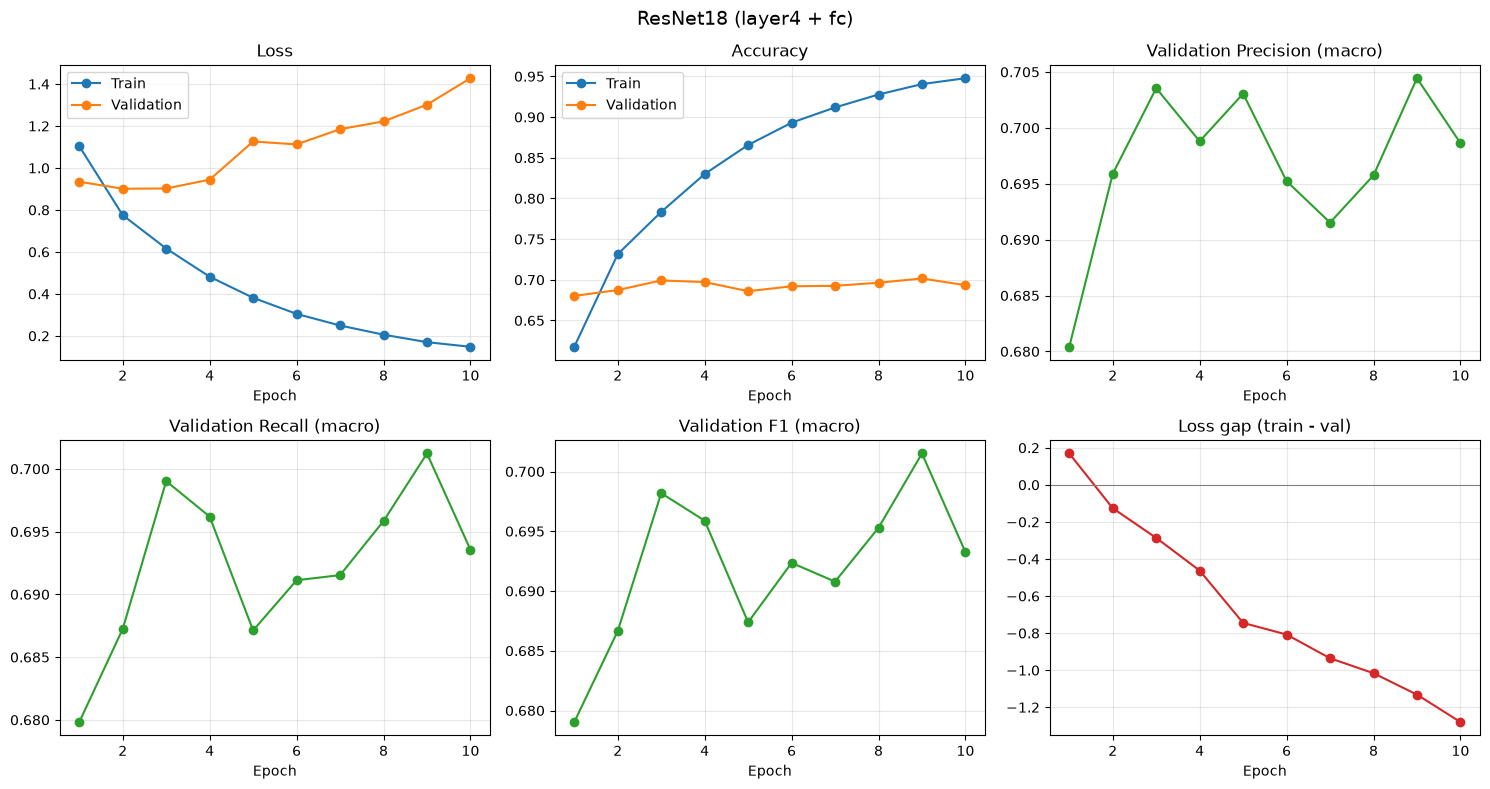


=== ResNet18 (layer3-4 + fc) ===
Trainable params: 10,498,570 / 11,181,642
Epoch 1/10 | train loss 0.9070 acc 0.6913 | val loss 0.7093 acc 0.7570 f1 0.7560
Epoch 2/10 | train loss 0.5893 acc 0.7984 | val loss 0.6869 acc 0.7600 f1 0.7551
Epoch 3/10 | train loss 0.4439 acc 0.8481 | val loss 0.6385 acc 0.7880 f1 0.7884
Epoch 4/10 | train loss 0.3355 acc 0.8852 | val loss 0.6665 acc 0.7912 f1 0.7905
Epoch 5/10 | train loss 0.2481 acc 0.9141 | val loss 0.7184 acc 0.7896 f1 0.7898
Epoch 6/10 | train loss 0.1914 acc 0.9343 | val loss 0.7805 acc 0.7890 f1 0.7878
Epoch 7/10 | train loss 0.1474 acc 0.9489 | val loss 0.8517 acc 0.7872 f1 0.7862
Epoch 8/10 | train loss 0.1213 acc 0.9580 | val loss 0.8584 acc 0.7890 f1 0.7880
Epoch 9/10 | train loss 0.1004 acc 0.9653 | val loss 0.8809 acc 0.7972 f1 0.7960
Epoch 10/10 | train loss 0.0824 acc 0.9708 | val loss 0.9267 acc 0.7880 f1 0.7876
Test: loss 0.9438 acc 0.7889 f1 0.7893


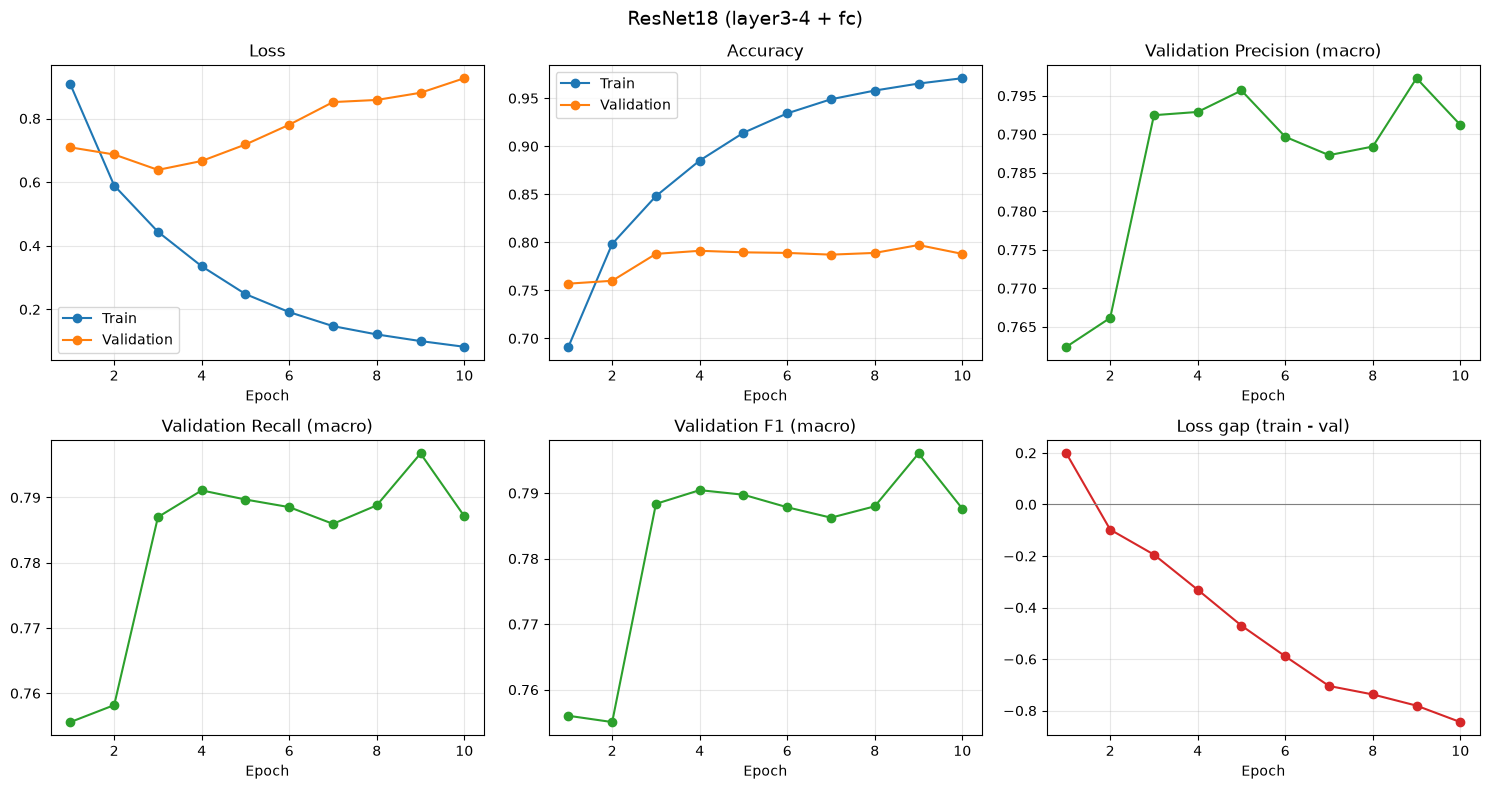


=== Custom CNN ===
Trainable params: 815,018 / 815,018
Epoch 1/10 | train loss 1.5330 acc 0.4326 | val loss 1.2446 acc 0.5678 f1 0.5695
Epoch 2/10 | train loss 1.1274 acc 0.5996 | val loss 0.9624 acc 0.6510 f1 0.6393
Epoch 3/10 | train loss 0.9664 acc 0.6616 | val loss 0.8989 acc 0.6812 f1 0.6712
Epoch 4/10 | train loss 0.8558 acc 0.7028 | val loss 0.7123 acc 0.7462 f1 0.7429
Epoch 5/10 | train loss 0.7985 acc 0.7279 | val loss 0.7269 acc 0.7356 f1 0.7336
Epoch 6/10 | train loss 0.7457 acc 0.7426 | val loss 0.6291 acc 0.7784 f1 0.7747
Epoch 7/10 | train loss 0.6950 acc 0.7618 | val loss 0.6222 acc 0.7796 f1 0.7764
Epoch 8/10 | train loss 0.6589 acc 0.7762 | val loss 0.5822 acc 0.7998 f1 0.7977
Epoch 9/10 | train loss 0.6297 acc 0.7853 | val loss 0.5498 acc 0.8082 f1 0.8079
Epoch 10/10 | train loss 0.6017 acc 0.7969 | val loss 0.5449 acc 0.8084 f1 0.8086
Test: loss 0.5569 acc 0.8066 f1 0.8070


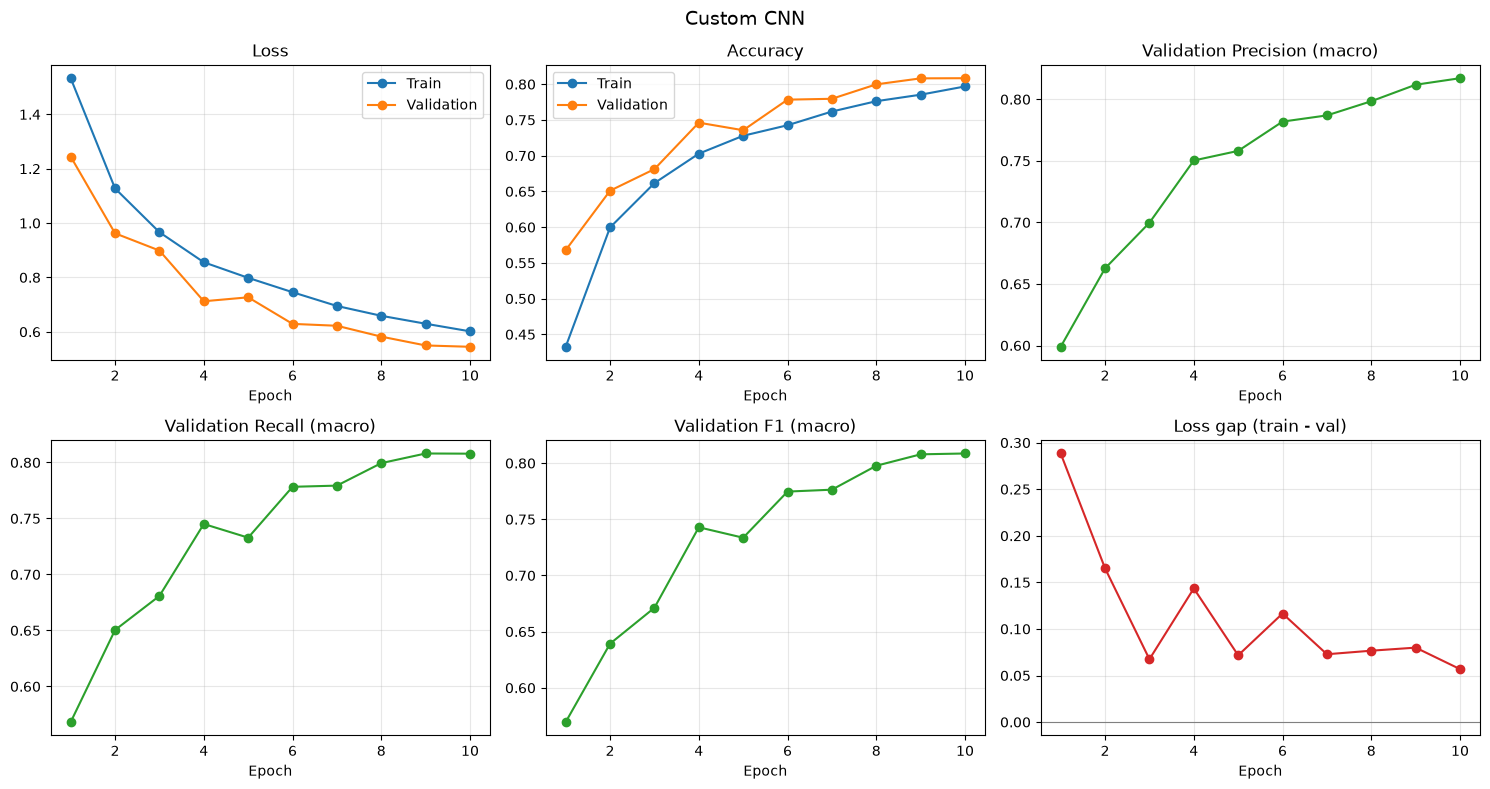

In [88]:
all_results["ResNet18 (fc only)"] = run_experiment(
    "ResNet18 (fc only)", build_resnet18(trainable_layers=()))

all_results["ResNet18 (layer4 + fc)"] = run_experiment(
    "ResNet18 (layer4 + fc)", build_resnet18(trainable_layers=("layer4",)))

all_results["ResNet18 (layer3-4 + fc)"] = run_experiment(
    "ResNet18 (layer3-4 + fc)", build_resnet18(trainable_layers=("layer3", "layer4")))

all_results["Custom CNN"] = run_experiment("Custom CNN", CustomCNN())

In [89]:
rows = []
for name, r in all_results.items():
    rows.append({"model": name,
                 "trainable_params": r["trainable_params"],
                 "train_time_s": round(r["train_time_s"], 1),
                 "test_loss": r["test"]["loss"],
                 "test_accuracy": r["test"]["accuracy"],
                 "test_precision": r["test"]["precision"],
                 "test_recall": r["test"]["recall"],
                 "test_f1": r["test"]["f1"]})
results_df = pd.DataFrame(rows).set_index("model")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("\n=== Results (test set) ===")
print(results_df.round(4))


=== Results (test set) ===
                          trainable_params  train_time_s  test_loss  test_accuracy  test_precision  test_recall  test_f1
model                                                                                                                   
ResNet18 (fc only)                    5130          22.8     1.5737         0.4595          0.4624       0.4595   0.4525
ResNet18 (layer4 + fc)             8398858          39.5     1.4506         0.6962          0.7013       0.6962   0.6960
ResNet18 (layer3-4 + fc)          10498570          53.3     0.9438         0.7889          0.7916       0.7889   0.7893
Custom CNN                          815018          56.3     0.5569         0.8066          0.8157       0.8066   0.8070


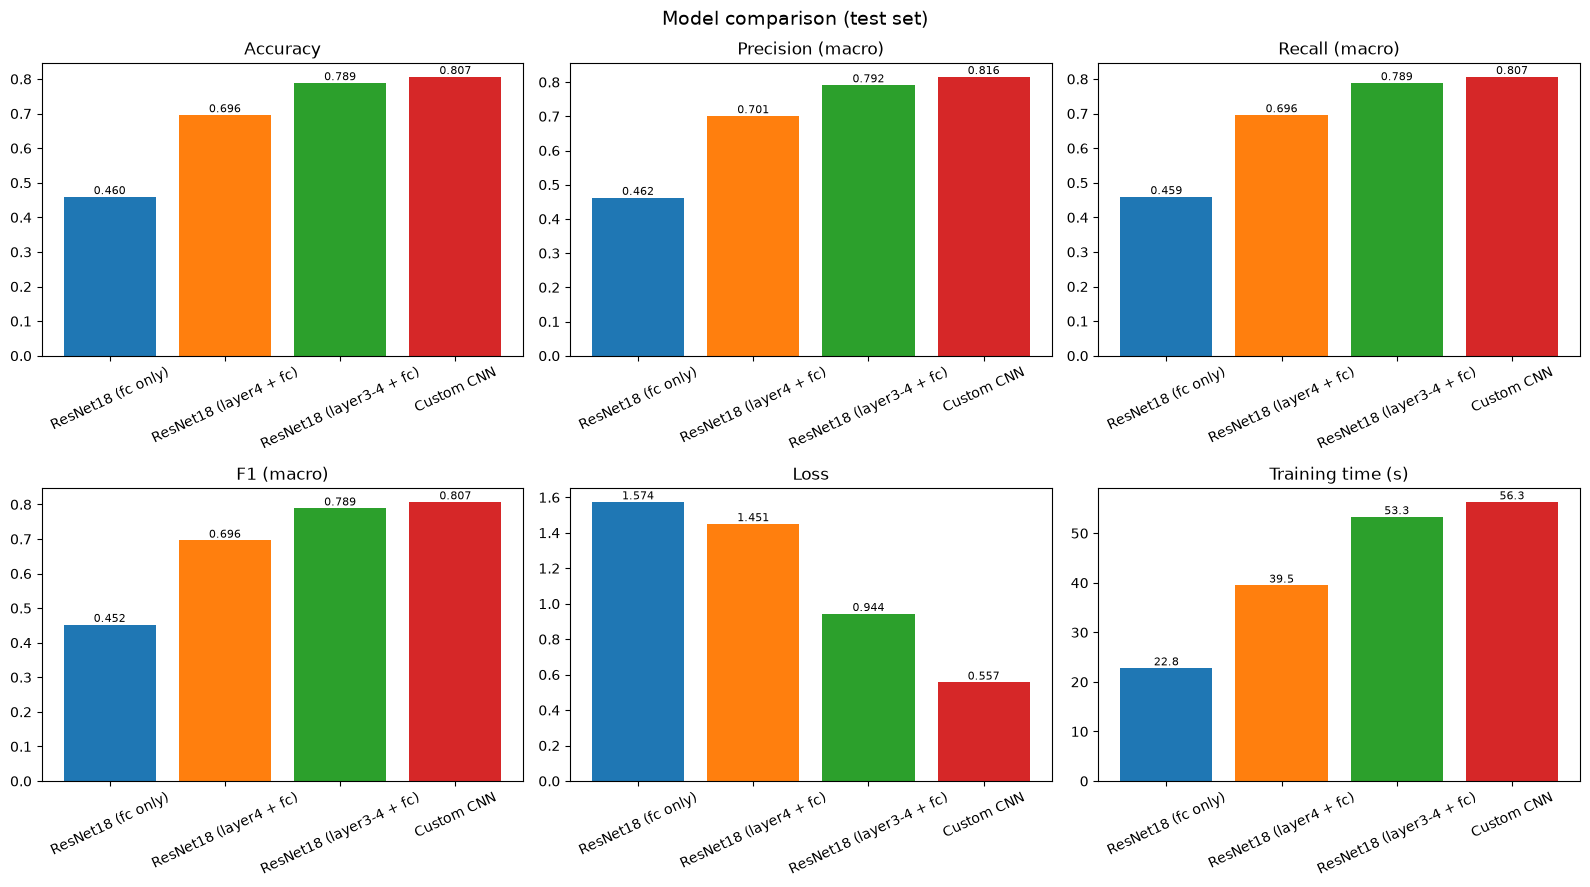

In [90]:
metrics = ["test_accuracy", "test_precision", "test_recall", "test_f1",
           "test_loss", "train_time_s"]
titles = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)",
          "Loss", "Training time (s)"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, m, t in zip(axes.ravel(), metrics, titles):
    bars = ax.bar(results_df.index, results_df[m],
                  color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
    ax.set_title(t)
    ax.tick_params(axis="x", rotation=25)
    ax.bar_label(bars, fmt="%.3f" if m != "train_time_s" else "%.1f", fontsize=8)
fig.suptitle("Model comparison (test set)", fontsize=14)
plt.tight_layout()
plt.show()

In [91]:
best_model = all_results["Custom CNN"]["model"]
torch.save({
    "state_dict": best_model.state_dict(),
    "classes": CLASSES,
    "mean": MEAN.flatten().tolist(),
    "std": STD.flatten().tolist(),
    "input_size": 32,
}, "custom_cnn_cifar10.pt")
print("Saved custom_cnn_cifar10.pt")

Saved custom_cnn_cifar10.pt
